# Cuaderno 06 - Regresión Logística y Métricas de Evaluacion

En este cuaderno vamos a trabajar con un problema de **clasificación binaria**.

En los cuadernos anteriores usamos modelos de regresión para predecir valores numéricos continuos. Por ejemplo, intentamos estimar una puntuación, un precio, una cantidad o algún otro valor expresado como número.

En esta oportunidad cambia el tipo de problema: ahora no queremos predecir “cuánto”, sino tomar una decisión entre dos opciones posibles.

Para eso vamos a usar un modelo llamado **regresión logística**. Aunque su nombre incluya la palabra “regresión”, este modelo se utiliza principalmente para resolver problemas de clasificación.

El objetivo será construir un modelo que intente predecir si un cliente de un banco contratará o no un depósito a plazo, a partir de distintas características personales, financieras y de contacto comercial.

## ¿Qué vamos a hacer en este cuaderno?

A lo largo del cuaderno vamos a seguir un recorrido completo de trabajo con un modelo de clasificación:

1. Cargar el dataset.
2. Explorar sus columnas y comprender qué representa cada variable.
3. Identificar la variable objetivo.
4. Analizar si las clases están balanceadas o desbalanceadas.
5. Seleccionar variables predictoras.
6. Preparar los datos para que puedan ser usados por el modelo.
7. Entrenar un modelo de regresión logística.
8. Evaluar sus resultados con distintas métricas.
9. Interpretar la matriz de confusión.
10. Reflexionar sobre los errores del modelo.

La idea no es solamente “hacer funcionar el código”, sino entender qué decisiones tomamos y por qué las tomamos.

## El problema: ¿el cliente contratará un depósito a plazo?

El dataset que vamos a utilizar contiene información relacionada con campañas de marketing directo realizadas por una entidad bancaria.

En este tipo de campañas, el banco contacta a diferentes clientes y registra información como edad, trabajo, estado civil, nivel educativo, saldo de la cuenta, préstamos existentes, tipo de contacto, mes de contacto y otros datos vinculados con la campaña.

La pregunta que queremos responder es:

**¿Podemos predecir si un cliente contratará un depósito a plazo?**

La respuesta posible es binaria:

- **yes**: el cliente contrató el depósito.
- **no**: el cliente no contrató el depósito.

Por lo tanto, estamos frente a un problema de **clasificación binaria**.

## Importación de librerías

Antes de cargar los datos, importamos las librerías que vamos a utilizar.

Usaremos:

- **pandas** para cargar y manipular el dataset.
- **numpy** para algunas operaciones numéricas.
- **matplotlib** para realizar gráficos.
- Herramientas de **Scikit-learn** para dividir los datos, entrenar el modelo y evaluar sus resultados.

También importaremos algunas métricas específicas para clasificación, como `accuracy_score`, `classification_report` y `confusion_matrix`.

In [23]:
# ==========================================================
# IMPORTAMOS LAS LIBRERÍAS PRINCIPALES
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Carga del dataset

Como en cuadernos anteriores, vamos a escribir una celda que primero verifique si el archivo ya está disponible en el entorno de Colab.

Si el archivo ya fue subido manualmente, lo usamos directamente. Si no está disponible, lo descargamos desde Kaggle usando `kagglehub`.

En este caso vamos a intentar trabajar con el archivo `bank-full.csv`, que contiene la versión completa del dataset. Si por algún motivo solo estuviera disponible `bank.csv`, también podríamos usarlo, aunque contiene menos registros.

Dataset [disponible en Kaggle](https://www.kaggle.com/datasets/dharmik34/bank-term-deposit-subscription)

> Una aclaración importante: este dataset viene separado por punto y coma (`;`) y no por coma. Por eso, al leerlo con `pd.read_csv()`, vamos a indicar `sep=";"`.

## Importación de librerías

Antes de comenzar a trabajar con los datos, necesitamos importar algunas librerías de Python que nos van a acompañar a lo largo de todo el cuaderno.

Vamos a usar:

- **pandas** para cargar y manipular el dataset,
- **numpy** para algunas operaciones numéricas,
- **matplotlib** para realizar gráficos,
- y herramientas de **Scikit-learn** para dividir los datos, entrenar el modelo de regresión lineal y evaluar sus resultados.

In [19]:
# ==========================================================
# IMPORTAMOS LAS LIBRERÍAS PRINCIPALES
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Carga del dataset

Como ya vimos en cuadernos anteriores, el primer paso consiste en cargar el dataset con el que vamos a trabajar.

En este caso volveremos a usar el conjunto de datos **"Popular Video Games 1980-2023"**. No nos detendremos demasiado en esta etapa, ya que tanto la carga de datos como la exploración inicial y algunas tareas de preparación forman parte de un flujo de trabajo que ya conocemos.

Nuestro interés, en esta oportunidad, estará puesto principalmente en otra cuestión: cómo adaptar ese dataset para plantear un problema de **regresión**, entrenar un modelo y evaluar qué tan buenas son sus predicciones.

In [4]:
# ==========================================================
# CARGAMOS EL DATASET
# ==========================================================

# Si el archivo ya está disponible en una ruta local, lo usamos directamente.
# En caso contrario, lo descargamos desde Kaggle.

ruta_local = "/content/bank.csv"

if os.path.exists(ruta_local):
    ruta_csv = ruta_local
else:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download("dharmik34/bank-term-deposit-subscription")
    ruta_csv = os.path.join(ruta_dataset, "bank.csv")

bank = pd.read_csv(ruta_csv, sep=";") #ojo: el separado en este dataset es ";"

print("Dataset cargado correctamente.")
print("Dimensiones:", bank.shape)

display(bank.head())

Using Colab cache for faster access to the 'bank-term-deposit-subscription' dataset.
Dataset cargado correctamente.
Dimensiones: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Primer vistazo al dataset

Una vez cargado el dataset, conviene hacer una revisión inicial.

En esta primera exploración no buscamos sacar conclusiones definitivas, sino entender con qué tipo de información estamos trabajando.

Vamos a revisar:

- los nombres de las columnas,
- los tipos de datos,
- la cantidad de filas y columnas,
- un resumen estadístico de las variables numéricas,
- y la presencia de posibles valores nulos.

Este paso es importante porque antes de entrenar un modelo necesitamos entender qué representa cada columna y si los datos están en condiciones de ser utilizados.

In [5]:
# ==========================================================
# EXPLORACIÓN INICIAL DE LA ESTRUCTURA DEL DATASET
# ==========================================================

print("Columnas del dataset:")
print(bank.columns.tolist())

print("\nInformación general:")
bank.info()

print("\nResumen estadístico de las variables numéricas:")
display(bank.describe())

print("\nCantidad de valores nulos por columna:")
display(bank.isnull().sum())

Columnas del dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000



Cantidad de valores nulos por columna:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Interpretación de la exploración inicial

El dataset tiene **4521 filas** y **17 columnas**. Cada fila representa un cliente contactado durante una campaña bancaria, y cada columna contiene alguna característica asociada a ese cliente o a la campaña.

Vemos que no hay valores nulos en ninguna columna, lo cual simplifica bastante el trabajo inicial. Esto no significa que el dataset esté “perfecto”, pero sí que no necesitamos resolver, al menos por ahora, problemas de datos faltantes.

También observamos que hay dos grandes tipos de variables:

- Variables numéricas, como `age`, `balance`, `day`, `duration`, `campaign`, `pdays` y `previous`.
- Variables categóricas, como `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `poutcome` y `y`.

Esta diferencia es importante porque los modelos de Scikit-learn no pueden trabajar directamente con textos como `"admin."`, `"married"` o `"yes"`. Más adelante tendremos que transformar esas variables categóricas en valores numéricos.

La variable que queremos predecir es `y`. Esta columna indica si el cliente contrató o no el depósito a plazo ofrecido por el banco.

Por lo tanto:

- `y = "yes"` significa que el cliente contrató el producto.
- `y = "no"` significa que el cliente no lo contrató.

Como solo hay dos respuestas posibles, estamos frente a un problema de **clasificación binaria**.

Antes de entrenar cualquier modelo, vamos a revisar cómo se distribuyen esas dos clases. Esto es fundamental porque, si hay muchos más casos de una clase que de otra, algunas métricas pueden resultar engañosas.

Valores posibles de la variable objetivo:
['no' 'yes']

Cantidad de casos por clase:


,count
y,
no,4000
yes,521



Porcentaje de casos por clase:


,proportion
y,
no,88.476001
yes,11.523999


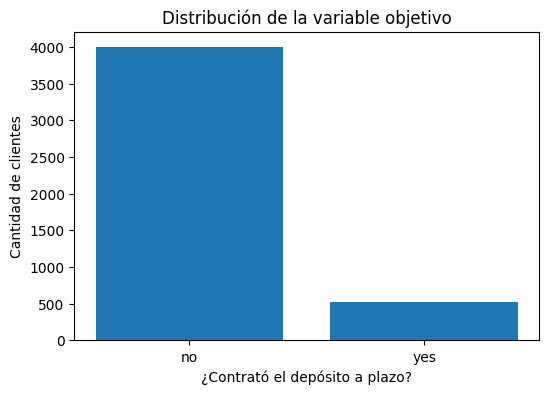

In [6]:
# ==========================================================
# ANALIZAMOS LA VARIABLE OBJETIVO
# ==========================================================

# La variable objetivo es la columna "y".
# Indica si el cliente contrató ("yes") o no contrató ("no")
# el depósito a plazo ofrecido por el banco.

print("Valores posibles de la variable objetivo:")
print(bank["y"].unique())

print("\nCantidad de casos por clase:")
display(bank["y"].value_counts())

print("\nPorcentaje de casos por clase:")
display(bank["y"].value_counts(normalize=True) * 100)

# ----------------------------------------------------------
# Graficamos la distribución de la variable objetivo
# ----------------------------------------------------------

conteo_clases = bank["y"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(conteo_clases.index, conteo_clases.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("¿Contrató el depósito a plazo?")
plt.ylabel("Cantidad de clientes")
plt.show()

## Distribución de la variable objetivo

El gráfico muestra que la mayoría de los clientes **no contrató** el depósito a plazo.

Esto significa que el dataset está **desbalanceado**: hay muchos más casos de la clase `no` que de la clase `yes`.

Este detalle es muy importante para evaluar el modelo.

Si un modelo predijera siempre `no`, acertaría en una gran cantidad de casos, simplemente porque esa es la clase más frecuente. Sin embargo, ese modelo no sería realmente útil, porque no detectaría a los clientes que sí podrían contratar el producto.

Por eso, en problemas de clasificación no alcanza con mirar solamente la métrica `accuracy`.

La precisión general nos dice cuántas veces acierta el modelo en total, pero no nos dice si está detectando bien la clase que más nos interesa.

En este caso, la clase `yes` puede ser especialmente importante para el banco, porque representa a los clientes que efectivamente contrataron el depósito. Más adelante vamos a usar métricas como `recall`, `precision`, `F1-score` y la matriz de confusión para analizar el comportamiento del modelo con más detalle.

In [7]:
# ==========================================================
# ANALIZAMOS LOS TIPOS DE VARIABLES DISPONIBLES
# ==========================================================

# Separamos las columnas según su tipo de dato.
# Las variables numéricas ya están representadas como números.
# Las variables categóricas contienen texto y más adelante deberán transformarse.

columnas_numericas = bank.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = bank.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

# ----------------------------------------------------------
# Revisamos cuántos valores diferentes tiene cada columna
# categórica. Esto nos ayuda a entender mejor el dataset.
# ----------------------------------------------------------

print("\nCantidad de valores únicos en cada variable categórica:")
for columna in columnas_categoricas:
    print(f"{columna}: {bank[columna].nunique()} valores únicos")
    print(bank[columna].value_counts())
    print("-" * 50)

Columnas numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Columnas categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Cantidad de valores únicos en cada variable categórica:
job: 12 valores únicos
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
--------------------------------------------------
marital: 3 valores únicos
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64
--------------------------------------------------
education: 4 valores únicos
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64
--------------------------------------------------
default: 2 valores únicos

## Análisis de las variables disponibles

El dataset combina variables **numéricas** y **categóricas**.

Las variables numéricas son:

- `age`: edad del cliente.
- `balance`: saldo de la cuenta.
- `day`: día del mes en que se realizó el contacto.
- `duration`: duración del último contacto, en segundos.
- `campaign`: cantidad de contactos realizados durante esta campaña.
- `pdays`: cantidad de días desde el último contacto de una campaña anterior.
- `previous`: cantidad de contactos previos realizados antes de esta campaña.

Las variables categóricas son:

- `job`: tipo de trabajo del cliente.
- `marital`: estado civil.
- `education`: nivel educativo.
- `default`: si tiene crédito en default.
- `housing`: si tiene préstamo hipotecario.
- `loan`: si tiene préstamo personal.
- `contact`: tipo de contacto utilizado.
- `month`: mes del último contacto.
- `poutcome`: resultado de la campaña anterior.
- `y`: variable objetivo.

La variable `y` no debe usarse como predictora, porque es justamente lo que queremos predecir.

También es importante observar que algunas variables tienen la categoría `unknown`. Esto no aparece como valor nulo, pero sí representa información desconocida o no registrada. Por ejemplo, ocurre en `job`, `education`, `contact` y especialmente en `poutcome`.

Por ahora no vamos a eliminar esos registros. Los vamos a conservar como una categoría más, porque también pueden aportar información al modelo. Por ejemplo, que el resultado de una campaña anterior sea `unknown` puede indicar que el cliente nunca fue contactado antes.

Un caso especial es la columna `duration`.

Esta variable indica cuánto duró la llamada o contacto con el cliente. Puede ser muy predictiva: una llamada más larga probablemente esté asociada con mayor interés del cliente. Sin embargo, en un problema real, esta información solo se conoce **después** de haber llamado al cliente.

Por eso, si el objetivo fuera decidir de antemano a qué clientes conviene contactar, `duration` no sería una variable válida. En este cuaderno la vamos a dejar inicialmente fuera del modelo para construir un caso más realista: intentaremos predecir la contratación usando información disponible antes o al inicio de la campaña.

In [8]:
# ==========================================================
# SELECCIONAMOS VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ==========================================================

variables_predictoras = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

variable_objetivo = "y"

X = bank[variables_predictoras]
y = bank[variable_objetivo]

print("Variables predictoras seleccionadas:")
print(variables_predictoras)

print("\nVariable objetivo:")
print(variable_objetivo)

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())
display(y.head())

Variables predictoras seleccionadas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']

Variable objetivo:
y

Dimensiones de X: (4521, 15)
Dimensiones de y: (4521,)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,1,-1,0,unknown
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,1,339,4,failure
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,1,330,1,failure
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,4,-1,0,unknown
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,1,-1,0,unknown


,y
0,no
1,no
2,no
3,no
4,no


## Preparación de los datos

Ya separamos el dataset en dos partes:

- `X`: contiene las variables predictoras, es decir, la información que usaremos para intentar anticipar la respuesta.
- `y`: contiene la variable objetivo, es decir, la respuesta real que queremos predecir.

Sin embargo, todavía tenemos un problema: muchas columnas de `X` contienen texto.

Por ejemplo, columnas como `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month` y `poutcome` tienen valores categóricos como `"management"`, `"married"`, `"secondary"`, `"yes"`, `"no"` o `"cellular"`.

Sabemos que los modelos de Scikit-learn no trabajan directamente con texto. Necesitan que toda la información esté representada mediante números.

Por eso vamos a transformar las variables categóricas usando una técnica llamada **one-hot encoding**.

Ya vimos que esta técnica crea columnas nuevas para representar las categorías. Por ejemplo, una columna como `marital`, que puede tener los valores `"married"`, `"single"` o `"divorced"`, se transforma en varias columnas numéricas que indican con `True` o `False` si el cliente pertenece a cada categoría.

También vamos a transformar la variable objetivo `y`, que actualmente contiene `"yes"` y `"no"`, en valores numéricos:

- `"yes"` se convertirá en `1`.
- `"no"` se convertirá en `0`.

De esta forma, el modelo podrá entrenarse correctamente.

In [9]:
# ==========================================================
# CODIFICAMOS LAS VARIABLES CATEGÓRICAS Y LA VARIABLE OBJETIVO
# ==========================================================

X_codificado = pd.get_dummies(X, drop_first=True)

# Convertimos la variable objetivo:
# "yes" pasa a ser 1
# "no" pasa a ser 0

y_codificado = y.map({
    "no": 0,
    "yes": 1
})

print("Dimensiones originales de X:", X.shape)
print("Dimensiones de X después de aplicar one-hot encoding:", X_codificado.shape)

print("\nPrimeras filas de X codificado:")
display(X_codificado.head())

print("\nPrimeras filas de y codificado:")
display(y_codificado.head())

print("\nDistribución de la variable objetivo codificada:")
display(y_codificado.value_counts())

Dimensiones originales de X: (4521, 15)
Dimensiones de X después de aplicar one-hot encoding: (4521, 41)

Primeras filas de X codificado:


,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,1,-1,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,33,4789,11,1,339,4,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,35,1350,16,1,330,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,4,-1,0,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
4,59,0,5,1,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True



Primeras filas de y codificado:


,y
0,0
1,0
2,0
3,0
4,0



Distribución de la variable objetivo codificada:


,count
y,
0,4000
1,521


## Resultado de la codificación

Después de aplicar `pd.get_dummies()`, las variables categóricas fueron transformadas en columnas numéricas.

Por ejemplo, una columna como `job`, que contenía categorías como `"management"`, `"technician"` o `"blue-collar"`, ahora se representa mediante varias columnas binarias, como `job_management`, `job_technician`, `job_blue-collar`, etc.

Cada una de esas columnas indica si el cliente pertenece o no a esa categoría.

También transformamos la variable objetivo:

- `0` representa a los clientes que **no contrataron** el depósito.
- `1` representa a los clientes que **sí contrataron** el depósito.

El dataset codificado tiene ahora **41 columnas predictoras**. Esto no significa que hayamos agregado información nueva, sino que representamos la información categórica de una manera que el modelo pueda procesar.

El próximo paso será dividir los datos en dos conjuntos:

- un conjunto de **entrenamiento**, que el modelo usará para aprender;
- un conjunto de **prueba**, que usaremos para evaluar cómo se comporta con datos que no vio durante el entrenamiento.

Además, como la variable objetivo está desbalanceada, usaremos el parámetro `stratify=y_codificado`. Esto ayuda a que la proporción de casos `0` y `1` sea parecida tanto en el conjunto de entrenamiento como en el conjunto de prueba.

In [12]:
# ==========================================================
# DIVIDIMOS LOS DATOS EN ENTRENAMIENTO Y PRUEBA
# ==========================================================

# Usamos el 80% de los datos para entrenar el modelo
# y el 20% restante para evaluar su rendimiento.
#
# El parámetro stratify=y_codificado permite conservar una proporción
# similar de casos 0 y 1 en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X_codificado,
    y_codificado,
    test_size=0.2,
    random_state=42,
    stratify=y_codificado
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)

print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True) * 100)

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True) * 100)

Dimensiones de X_train: (3616, 41)
Dimensiones de X_test: (905, 41)

Distribución de clases en y_train:


,proportion
y,
0,88.46792
1,11.53208



Distribución de clases en y_test:


,proportion
y,
0,88.508287
1,11.491713


## División estratificada de los datos

La división entre entrenamiento y prueba conserva prácticamente la misma proporción de clases que tenía el dataset original.

En ambos conjuntos, alrededor del **88,5%** de los casos corresponde a clientes que no contrataron el depósito (`0`), mientras que cerca del **11,5%** corresponde a clientes que sí lo contrataron (`1`).

> Esto es importante porque, si la división se hiciera al azar sin cuidar la proporción de clases, podría ocurrir que el conjunto de prueba tuviera muy pocos casos positivos. En ese caso, la evaluación del modelo sería menos confiable.

El uso de `stratify=y_codificado` ayuda a evitar ese problema, manteniendo una distribución similar de la variable objetivo en ambos conjuntos.

Ahora que ya tenemos los datos preparados, podemos entrenar nuestro primer modelo de regresión logística.

In [15]:
# ==========================================================
# ENTRENAMOS UN MODELO DE REGRESIÓN LOGÍSTICA
# ==========================================================

# Creamos el modelo.
# max_iter aumenta la cantidad máxima de iteraciones para darle
# más margen al algoritmo de entrenamiento.
#
# class_weight="balanced" le indica al modelo que tenga en cuenta
# el desbalance entre las clases. Como la clase 1 aparece mucho menos,
# el modelo le dará más peso durante el entrenamiento.

modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Entrenamos el modelo usando los datos de entrenamiento.

modelo_logistico.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## ¿Qué pasó con el entrenamiento?

El modelo se entrenó, pero Scikit-learn mostró una advertencia llamada `ConvergenceWarning`.

Esto significa que el algoritmo de optimización no logró terminar completamente su proceso dentro del número máximo de iteraciones indicado.

No es exactamente un error: el código no se detuvo y el modelo existe. Sin embargo, la advertencia nos dice que el entrenamiento podría no haber llegado a una solución suficientemente estable.

Una causa frecuente de este problema es que las variables tienen escalas muy diferentes.

Por ejemplo, en nuestro dataset:

- `age` tiene valores entre 19 y 87.
- `balance` puede llegar a valores muy altos, como 71188.
- `pdays` puede llegar a 871.
- las variables creadas con one-hot encoding son binarias, es decir, toman valores como `True` o `False`.

Cuando las variables están en escalas tan distintas, algunos modelos pueden tener dificultades para ajustar sus parámetros.

Para resolverlo, vamos a aplicar un proceso llamado **escalado de variables**.

El escalado transforma las variables numéricas para que queden en una escala más comparable. Esto no cambia la información de fondo del dataset, pero ayuda al algoritmo a entrenarse de manera más estable.

In [16]:
# ==========================================================
# ESCALAMOS LOS DATOS Y VOLVEMOS A ENTRENAR EL MODELO
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Creamos el escalador.
# Lo ajustamos SOLO con los datos de entrenamiento.
#
# Esto es importante: el conjunto de prueba debe simular datos nuevos,
# por lo tanto no debemos usarlo para aprender parámetros de transformación.

escalador = StandardScaler()

X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

# Creamos nuevamente el modelo de regresión logística.
#
# Mantenemos class_weight="balanced" para compensar el desbalance
# entre las clases.

modelo_logistico = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Entrenamos el modelo usando los datos escalados.

modelo_logistico.fit(X_train_escalado, y_train)

print("Modelo entrenado correctamente con datos escalados.")

Modelo entrenado correctamente con datos escalados.


## Predicciones del modelo

Una vez entrenado el modelo, podemos usarlo para realizar predicciones sobre el conjunto de prueba.

El conjunto de prueba contiene datos que el modelo no usó durante el entrenamiento. Por eso nos sirve para estimar cómo podría comportarse frente a casos nuevos.

La regresión logística nos permite obtener dos tipos de salida:

- La **clase predicha**, es decir, si el modelo decide que el cliente pertenece a la clase `0` o a la clase `1`.
- La **probabilidad estimada**, es decir, qué tan probable considera el modelo que el cliente pertenezca a cada clase.

Por defecto, el modelo usa un umbral de decisión de `0.5`.

Esto significa que:

- si la probabilidad de pertenecer a la clase `1` es menor que `0.5`, predice `0`;
- si la probabilidad de pertenecer a la clase `1` es mayor o igual que `0.5`, predice `1`.

En nuestro caso:

- `0` significa que el cliente no contrataría el depósito.
- `1` significa que el cliente sí contrataría el depósito.

In [17]:
# ==========================================================
# REALIZAMOS PREDICCIONES CON EL MODELO
# ==========================================================

# Predicción de clases:
# devuelve directamente 0 o 1 para cada cliente del conjunto de prueba.

y_pred = modelo_logistico.predict(X_test_escalado)

# Predicción de probabilidades:
# devuelve la probabilidad estimada para cada clase.
#
# La columna 0 corresponde a la probabilidad de clase 0.
# La columna 1 corresponde a la probabilidad de clase 1.

y_proba = modelo_logistico.predict_proba(X_test_escalado)

print("Primeras 10 clases reales:")
print(y_test.values[:10])

print("\nPrimeras 10 clases predichas:")
print(y_pred[:10])

print("\nPrimeras 10 probabilidades estimadas:")
display(pd.DataFrame(
    y_proba[:10],
    columns=["Probabilidad clase 0", "Probabilidad clase 1"]
))

Primeras 10 clases reales:
[1 0 0 0 0 0 0 1 1 0]

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 1 1 0]

Primeras 10 probabilidades estimadas:


,Probabilidad clase 0,Probabilidad clase 1
0,0.609971,0.390029
1,0.841928,0.158072
2,0.602284,0.397716
3,0.812105,0.187895
4,0.725322,0.274678
5,0.824932,0.175068
6,0.616328,0.383672
7,0.431914,0.568086
8,0.292986,0.707014
9,0.855010,0.144990


## Interpretación de las primeras predicciones

En las primeras filas podemos comparar tres cosas:

- la clase real,
- la clase predicha por el modelo,
- y la probabilidad estimada para cada clase.

Por ejemplo, en el primer caso, la clase real era `1`, es decir, el cliente sí contrató el depósito. Sin embargo, el modelo predijo `0`.

Si miramos las probabilidades, vemos que el modelo estimó aproximadamente:

- 61% de probabilidad para la clase `0`;
- 39% de probabilidad para la clase `1`.

Como la probabilidad de la clase `1` quedó por debajo del umbral de `0.5`, el modelo decidió clasificar ese caso como `0`.

En cambio, en otros casos, como el octavo y el noveno ejemplo, la probabilidad de la clase `1` superó el umbral de `0.5`, y por eso el modelo predijo `1`.

Esto nos permite entender que la regresión logística trabaja en dos pasos:

1. estima una probabilidad;
2. transforma esa probabilidad en una decisión.

Por eso, en algunos problemas puede tener sentido modificar el umbral de decisión. Sin embargo, en este primer modelo vamos a mantener el umbral estándar de `0.5` para concentrarnos en las métricas principales.

## Primera métrica: accuracy

La primera métrica que vamos a calcular es la **accuracy**, también llamada precisión general o exactitud.

Esta métrica responde una pregunta muy simple:

**¿Qué porcentaje de predicciones hizo correctamente el modelo?**

Para calcularla, se compara la clase real de cada caso con la clase predicha por el modelo. Luego se cuenta cuántas predicciones fueron correctas y se divide ese número por el total de predicciones realizadas.

Por ejemplo, si el modelo evaluó 100 clientes y acertó en 85 casos, entonces su accuracy sería del 85%.

La fórmula general es:

$$
accuracy = \frac{\text{predicciones correctas}}{\text{total de predicciones}}
$$

En problemas donde las clases están equilibradas, esta métrica puede ser bastante útil. Sin embargo, en datasets desbalanceados, como el nuestro, puede resultar engañosa.

Recordemos que en este dataset la mayoría de los clientes pertenece a la clase `0`, es decir, clientes que no contrataron el depósito. Por eso, un modelo que predijera casi siempre `0` podría obtener un accuracy aparentemente alto, aunque detectara mal a los clientes que sí contrataron.

Por ese motivo, vamos a calcular accuracy, pero no nos vamos a quedar solamente con esa métrica.

In [20]:
# ==========================================================
# CALCULAMOS EL ACCURACY DEL MODELO
# ==========================================================

# El accuracy mide la proporción total de predicciones correctas.
# Compara las clases reales del conjunto de prueba con las clases predichas.

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)
print(f"Accuracy del modelo: {accuracy:.2%}")

Accuracy del modelo: 0.7060773480662983
Accuracy del modelo: 70.61%


## Interpretación del accuracy

El modelo obtuvo un **accuracy de aproximadamente 70,61%**.

Esto significa que, sobre el conjunto de prueba, acertó alrededor de 71 de cada 100 predicciones.

A primera vista, podría parecer un resultado aceptable. Sin embargo, debemos compararlo con la distribución de clases del dataset.

Recordemos que cerca del **88,5%** de los clientes del conjunto de prueba pertenecía a la clase `0`, es decir, clientes que no contrataron el depósito.

Esto significa que un modelo extremadamente simple, que predijera siempre `0`, tendría un accuracy cercano al 88,5%.

Entonces, ¿nuestro modelo es peor que ese modelo simple?

No necesariamente.

Como usamos `class_weight="balanced"`, le pedimos al modelo que no se concentre solamente en acertar la clase mayoritaria, sino que también intente detectar la clase minoritaria, es decir, los clientes que sí contrataron el depósito.

Por eso, puede bajar el accuracy general, pero mejorar la detección de los casos positivos.

Para entender mejor qué está ocurriendo, necesitamos mirar otras métricas. En particular, vamos a analizar:

- `precision`,
- `recall`,
- `F1-score`,
- y la matriz de confusión.

Estas métricas nos van a mostrar no solo cuánto acierta el modelo, sino también **cómo se equivoca**.

## Precision, recall y F1-score

El accuracy nos da una mirada general, pero no alcanza para entender bien el comportamiento del modelo.

En problemas de clasificación binaria, especialmente cuando las clases están desbalanceadas, necesitamos observar con más detalle qué ocurre con la clase positiva.

En este cuaderno, la clase positiva es:

$$
1 = \text{el cliente sí contrató el depósito}
$$

Vamos a analizar tres métricas importantes:

###**Precision**

La precision responde esta pregunta:

**De todos los clientes que el modelo predijo como `1`, ¿cuántos realmente contrataron el depósito?**

Es decir, mide qué tan confiables son las predicciones positivas del modelo.

Si la precision es baja, significa que el modelo está marcando como posibles contratantes a muchos clientes que finalmente no contrataron.

###**Recall**

El recall responde esta otra pregunta:

**De todos los clientes que realmente contrataron el depósito, ¿cuántos logró detectar el modelo?**

Esta métrica es muy importante cuando nos interesa no perder casos positivos.

En nuestro ejemplo, un recall alto significa que el modelo logra identificar una buena parte de los clientes que sí contrataron.

###**F1-score**

El F1-score combina precision y recall en un solo valor.

Es útil cuando queremos evaluar si el modelo mantiene un equilibrio razonable entre detectar positivos y no equivocarse demasiado al predecir positivos.

Si precision o recall son muy bajos, el F1-score también baja.

Por eso, en datasets desbalanceados, el F1-score suele ser más informativo que el accuracy.

In [24]:
# ==========================================================
# CALCULAMOS PRECISION, RECALL Y F1-SCORE
# ==========================================================

# classification_report muestra varias métricas para cada clase.
#
# Para la clase 0:
# evalúa cómo se comporta el modelo con los clientes que no contrataron.
#
# Para la clase 1:
# evalúa cómo se comporta el modelo con los clientes que sí contrataron.

reporte = classification_report(
    y_test,
    y_pred,
    target_names=["No contrató", "Sí contrató"]
)

print(reporte)

              precision    recall  f1-score   support

 No contrató       0.94      0.72      0.81       801
 Sí contrató       0.22      0.62      0.33       104

    accuracy                           0.71       905
   macro avg       0.58      0.67      0.57       905
weighted avg       0.85      0.71      0.76       905



## Interpretación del reporte de clasificación

El reporte de clasificación nos muestra que el modelo se comporta de manera muy diferente según la clase que esté intentando predecir.

Para la clase **No contrató**, el modelo obtuvo:

- **precision = 0.94**
- **recall = 0.72**
- **F1-score = 0.81**

Esto significa que, cuando el modelo predice que un cliente no contratará, suele acertar bastante. Sin embargo, no detecta todos los casos de esta clase, porque parte de los clientes que no contrataron son clasificados erróneamente como si fueran posibles contratantes.

Para la clase **Sí contrató**, que es la clase positiva y minoritaria, el resultado es más delicado:

- **precision = 0.22**
- **recall = 0.62**
- **F1-score = 0.33**

El **recall de 0.62** indica que el modelo logró detectar aproximadamente el 62% de los clientes que realmente contrataron el depósito.

Esto es interesante, porque la clase positiva representa solo una pequeña parte del dataset. El modelo no la ignora completamente.

Sin embargo, la **precision de 0.22** es baja. Esto significa que, de todos los clientes que el modelo marcó como posibles contratantes, muchos en realidad no contrataron.

En términos del problema bancario, el modelo parece estar siguiendo una estrategia amplia: intenta no perder demasiados clientes potencialmente interesados, pero a cambio genera muchos falsos positivos.

Esto puede ser aceptable o no según el objetivo del banco. Si contactar clientes tiene bajo costo, podría ser razonable priorizar el recall. Pero si cada contacto comercial es caro o molesto para el cliente, entonces sería importante mejorar la precision.

El F1-score de la clase positiva queda en **0.33**, lo que muestra que todavía hay un desequilibrio importante entre detectar clientes interesados y hacer predicciones positivas confiables.

## Matriz de confusión

El reporte de clasificación nos dio varias métricas útiles, pero todavía estamos viendo los resultados en forma de porcentajes o proporciones.

La **matriz de confusión** nos permite ver los aciertos y errores del modelo en números concretos.

En un problema de clasificación binaria, la matriz compara:

- la clase real de cada caso;
- la clase predicha por el modelo.

En nuestro caso, las clases son:

- `0`: el cliente no contrató el depósito.
- `1`: el cliente sí contrató el depósito.

La matriz nos permite identificar cuatro situaciones:

- **Verdaderos negativos (VN)**: clientes que no contrataron y el modelo predijo correctamente como `0`.
- **Falsos positivos (FP)**: clientes que no contrataron, pero el modelo predijo como `1`.
- **Falsos negativos (FN)**: clientes que sí contrataron, pero el modelo predijo como `0`.
- **Verdaderos positivos (VP)**: clientes que sí contrataron y el modelo predijo correctamente como `1`.

Esta información es muy importante porque nos permite responder preguntas más concretas:

* ¿A cuántos clientes interesados no detectó el modelo?

* ¿A cuántos clientes marcó como interesados aunque en realidad no contrataron?

 * ¿El modelo se equivoca más en una dirección que en otra?

Matriz de confusión:
[[574 227]
 [ 39  65]]


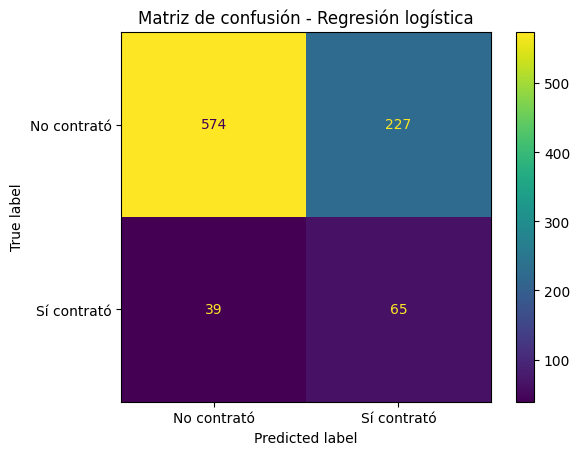

In [25]:
# ==========================================================
# CALCULAMOS Y GRAFICAMOS LA MATRIZ DE CONFUSIÓN
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz de confusión.
# Filas: clases reales.
# Columnas: clases predichas.

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

# ----------------------------------------------------------
# Mostramos la matriz de confusión como gráfico
# ----------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["No contrató", "Sí contrató"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión nos permite ver con más detalle qué hizo el modelo.

Los resultados fueron:

- **574 verdaderos negativos**: clientes que no contrataron el depósito y el modelo predijo correctamente como `No contrató`.
- **227 falsos positivos**: clientes que no contrataron, pero el modelo predijo como `Sí contrató`.
- **39 falsos negativos**: clientes que sí contrataron, pero el modelo predijo como `No contrató`.
- **65 verdaderos positivos**: clientes que sí contrataron y el modelo predijo correctamente como `Sí contrató`.

Esto confirma lo que ya habíamos visto en el reporte de clasificación.

El modelo logró detectar **65 de los 104 clientes** que realmente contrataron el depósito. Es decir, encontró una parte importante de la clase positiva.

Sin embargo, para lograr eso también clasificó como posibles contratantes a **227 clientes que en realidad no contrataron**. Por eso la precision de la clase positiva era baja.

> En términos del problema bancario, el modelo podría ser útil si el objetivo es armar una lista amplia de clientes potencialmente interesados, aceptando que muchos de ellos finalmente no contratarán.

> Pero si el banco necesita una lista más precisa, con menos contactos innecesarios, este modelo todavía debería mejorarse.

La matriz de confusión nos ayuda a entender que el problema no es simplemente “cuánto acierta” el modelo, sino **qué tipo de errores comete**.

In [26]:
# ==========================================================
# CALCULAMOS MÉTRICAS A PARTIR DE LA MATRIZ DE CONFUSIÓN
# ==========================================================

# Extraemos los valores de la matriz.
#
# La matriz tiene esta estructura:
#
# [[VN, FP],
#  [FN, VP]]

VN, FP, FN, VP = matriz.ravel()

print("Verdaderos negativos (VN):", VN)
print("Falsos positivos (FP):", FP)
print("Falsos negativos (FN):", FN)
print("Verdaderos positivos (VP):", VP)

# ----------------------------------------------------------
# Calculamos precision y recall para la clase positiva
# ----------------------------------------------------------

precision_positiva = VP / (VP + FP)
recall_positivo = VP / (VP + FN)

f1_positivo = 2 * (precision_positiva * recall_positivo) / (precision_positiva + recall_positivo)

print("\nMétricas para la clase positiva:")
print(f"Precision: {precision_positiva:.2f}")
print(f"Recall: {recall_positivo:.2f}")
print(f"F1-score: {f1_positivo:.2f}")

Verdaderos negativos (VN): 574
Falsos positivos (FP): 227
Falsos negativos (FN): 39
Verdaderos positivos (VP): 65

Métricas para la clase positiva:
Precision: 0.22
Recall: 0.62
F1-score: 0.33


## ¿De dónde salen precision, recall y F1-score?

Ahora podemos ver que las métricas del reporte no aparecen “mágicamente”, sino que se calculan a partir de los valores de la matriz de confusión.

Para la clase positiva, es decir, los clientes que **sí contrataron**, tenemos:

- `VP = 65`: clientes que sí contrataron y fueron detectados correctamente.
- `FP = 227`: clientes que no contrataron, pero fueron clasificados como si fueran posibles contratantes.
- `FN = 39`: clientes que sí contrataron, pero el modelo no logró detectarlos.

La **precision** se calcula así:

$$
precision = \frac{VP}{VP + FP}
$$

En nuestro caso:

$$
precision = \frac{65}{65 + 227} \approx 0.22
$$

Esto significa que, de todos los clientes que el modelo marcó como posibles contratantes, solo alrededor del **22%** realmente contrató.

El **recall** se calcula así:

$$
recall = \frac{VP}{VP + FN}
$$

En nuestro caso:

$$
recall = \frac{65}{65 + 39} \approx 0.62
$$

Esto significa que el modelo logró detectar alrededor del **62%** de los clientes que efectivamente contrataron.

El **F1-score** combina precision y recall. En este caso es de aproximadamente **0.33**, lo que muestra que el modelo todavía tiene dificultades para lograr un buen equilibrio entre detectar clientes interesados y evitar demasiados falsos positivos.

Esta lectura es mucho más rica que mirar solamente el accuracy.

## Probabilidades y umbral de decisión

**La regresión logística no predice directamente una clase de manera “cerrada”.**

Primero estima una probabilidad. En nuestro caso, estima la probabilidad de que un cliente pertenezca a la clase positiva:

$$
1 = \text{Sí contrató}
$$

Luego, esa probabilidad se transforma en una decisión usando un **umbral de corte**.

Por defecto, Scikit-learn usa un umbral de `0.5`.

Eso significa:

- si la probabilidad de la clase `1` es menor que `0.5`, el modelo predice `0`;
- si la probabilidad de la clase `1` es mayor o igual que `0.5`, el modelo predice `1`.

Pero ese umbral no es una ley fija. Podemos modificarlo según el objetivo del problema.

Por ejemplo:

- Si bajamos el umbral, el modelo clasificará más clientes como posibles contratantes. Esto puede aumentar el recall, pero también generar más falsos positivos.
- Si subimos el umbral, el modelo será más exigente para predecir `1`. Esto puede mejorar la precision, pero también puede hacer que se escapen más clientes que sí contratarían.

Vamos a probar distintos umbrales para ver cómo cambian las métricas.

In [27]:
# ==========================================================
# PROBAMOS DISTINTOS UMBRALES DE DECISIÓN
# ==========================================================

from sklearn.metrics import precision_score, recall_score, f1_score

# Tomamos solamente la probabilidad de la clase positiva.
# Es decir, la probabilidad de que el cliente sí contrate.

probabilidad_clase_positiva = y_proba[:, 1]

umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]

resultados_umbrales = []

for umbral in umbrales:
    # Si la probabilidad de clase positiva supera el umbral,
    # clasificamos el caso como 1. Si no, como 0.

    y_pred_umbral = (probabilidad_clase_positiva >= umbral).astype(int)

    precision = precision_score(y_test, y_pred_umbral)
    recall = recall_score(y_test, y_pred_umbral)
    f1 = f1_score(y_test, y_pred_umbral)

    resultados_umbrales.append({
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

resultados_umbrales = pd.DataFrame(resultados_umbrales)

display(resultados_umbrales)

,umbral,precision,recall,f1_score
0,0.3,0.144172,0.903846,0.248677
1,0.4,0.168103,0.750000,0.274648
2,0.5,0.222603,0.625000,0.328283
3,0.6,0.285714,0.423077,0.341085
4,0.7,0.378049,0.298077,0.333333


## Interpretación de los distintos umbrales

La tabla muestra que el modelo cambia bastante según el umbral de decisión que usamos.

Con un umbral bajo, como `0.3`, el modelo clasifica a muchos clientes como posibles contratantes. Por eso logra un **recall muy alto**, aproximadamente `0.90`.

Esto significa que detecta casi todos los clientes que realmente contrataron. Sin embargo, la **precision es muy baja**, aproximadamente `0.14`. Es decir, muchos de los clientes marcados como posibles contratantes en realidad no contrataron.

Con un umbral más alto, como `0.7`, ocurre lo contrario. El modelo se vuelve más exigente para predecir la clase `1`.

En ese caso, la **precision sube** a aproximadamente `0.38`, pero el **recall baja** a aproximadamente `0.30`. Es decir, las predicciones positivas son más confiables, pero se escapan muchos clientes que sí contrataron.

El umbral `0.5`, que es el valor usado por defecto, queda en un punto intermedio:

- `precision`: aproximadamente `0.22`
- `recall`: aproximadamente `0.62`
- `F1-score`: aproximadamente `0.33`

En esta prueba, el mejor F1-score aparece cerca del umbral `0.6`, aunque la diferencia no es enorme. Esto muestra que no existe un único umbral “correcto” para todos los problemas.

La elección del umbral depende del objetivo:

* Si el banco quiere detectar la mayor cantidad posible de clientes interesados, podría usar un umbral más bajo, aceptando más falsos positivos.

* Si el banco quiere contactar solo a clientes con mayor probabilidad de contratar, podría usar un umbral más alto, aceptando perder algunos clientes potenciales.

Esta es una idea central en clasificación: el modelo no solo produce una predicción, sino que también puede ayudar a tomar decisiones ajustando el criterio con el que convertimos probabilidades en clases.

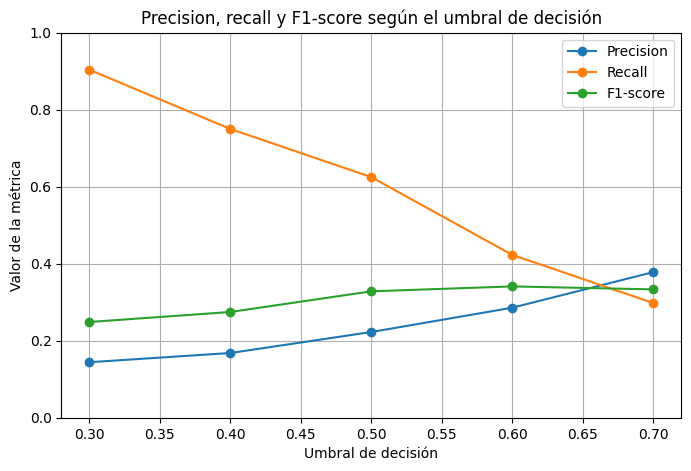

In [28]:
# ==========================================================
# GRAFICAMOS LAS MÉTRICAS SEGÚN EL UMBRAL
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(resultados_umbrales["umbral"], resultados_umbrales["precision"], marker="o", label="Precision")
plt.plot(resultados_umbrales["umbral"], resultados_umbrales["recall"], marker="o", label="Recall")
plt.plot(resultados_umbrales["umbral"], resultados_umbrales["f1_score"], marker="o", label="F1-score")

plt.title("Precision, recall y F1-score según el umbral de decisión")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

## Lectura del gráfico de umbrales

El gráfico muestra con claridad el intercambio entre `precision` y `recall`.

Cuando el umbral es bajo, como `0.3`, el modelo clasifica más clientes como posibles contratantes. Por eso el `recall` es alto: detecta una gran parte de los clientes que realmente contrataron. Sin embargo, la `precision` es baja, porque muchas de esas predicciones positivas son incorrectas.

Cuando el umbral aumenta, el modelo se vuelve más exigente para predecir la clase positiva. Entonces ocurre lo contrario: sube la `precision`, pero baja el `recall`.

El `F1-score` intenta resumir el equilibrio entre ambas métricas. En este caso, no alcanza valores muy altos, lo que indica que el modelo todavía tiene limitaciones para identificar con precisión a los clientes que sí contratarán.

Este análisis es importante porque muestra que el modelo no debe evaluarse de manera aislada. La elección del umbral depende del objetivo del problema.

* Si la campaña comercial tiene bajo costo y se quiere llegar a la mayor cantidad posible de clientes interesados, puede convenir un umbral más bajo.

* Si, en cambio, el contacto comercial es costoso o se quiere evitar molestar a clientes con baja probabilidad de contratar, puede convenir un umbral más alto.

## Conclusiones del cuaderno

En este cuaderno trabajamos con un problema de **clasificación binaria** usando un modelo de **regresión logística**.

A diferencia de los problemas de regresión lineal, donde buscamos predecir un valor numérico, en este caso el objetivo fue tomar una decisión entre dos clases posibles:

- `0`: el cliente no contrató el depósito.
- `1`: el cliente sí contrató el depósito.

El dataset resultó especialmente útil porque presentaba una situación muy común en problemas reales: las clases estaban desbalanceadas. La mayoría de los clientes no contrató el producto, mientras que solo una proporción pequeña sí lo hizo.

Este desbalance nos permitió ver por qué el `accuracy` no siempre alcanza para evaluar un modelo de clasificación.

El modelo obtuvo un accuracy cercano al 71%, pero ese número por sí solo no cuenta toda la historia. Al analizar el reporte de clasificación y la matriz de confusión, vimos que el modelo tenía un comportamiento más complejo:

- detectaba una parte importante de los clientes que sí contrataron;
- pero también generaba muchos falsos positivos;
- tenía buen desempeño para reconocer la clase mayoritaria;
- y más dificultades para identificar con precisión la clase minoritaria.

También vimos que la regresión logística no solo produce una clase final, sino una **probabilidad**. Esa probabilidad se transforma en una decisión mediante un **umbral de corte**.

Al modificar el umbral, comprobamos que el comportamiento del modelo cambia:

- con umbrales bajos, aumenta el `recall`, pero baja la `precision`;
- con umbrales altos, aumenta la `precision`, pero baja el `recall`;
- el `F1-score` ayuda a buscar un equilibrio entre ambas métricas.

Esta idea es fundamental: un modelo de clasificación no se evalúa solamente por cuántas veces acierta, sino por **qué tipo de errores comete** y por las consecuencias que esos errores pueden tener en el contexto del problema.

En una campaña bancaria, por ejemplo, no es lo mismo contactar a clientes que finalmente no contratarán que dejar afuera a clientes que sí estaban interesados. La elección de la métrica más importante depende del objetivo de negocio, del costo de los errores y de la estrategia que se quiera seguir.

En síntesis, en este cuaderno aprendimos a:

- reconocer un problema de clasificación binaria;
- preparar variables numéricas y categóricas para entrenar un modelo;
- entrenar una regresión logística;
- interpretar probabilidades y umbrales de decisión;
- evaluar el modelo con `accuracy`, `precision`, `recall`, `F1-score` y matriz de confusión;
- y analizar críticamente los resultados más allá de un único número.

La regresión logística es un modelo simple, eficiente e interpretable. Por eso resulta una excelente puerta de entrada al mundo de los clasificadores y a la evaluación de modelos de Machine Learning.